In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')
print('Libraries Ready')

Libraries Ready


In [23]:
df=pd.read_csv('heart_disease.csv')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
print(df.head())


Rows: 5050, Columns: 18
   age  gender   country  chest_pain_type  blood_pressure  cholesterol  \
0   67  Female  Pakistan                3           999.0         -1.0   
1   57    Male  Pakistan                2           999.0         -1.0   
2   43  Female       USA                2           999.0         -1.0   
3   71    Male     India                1           999.0         -1.0   
4   36    Male        UK                3           999.0         -1.0   

   blood_sugar  max_heart_rate  exercise_angina  smoker  diabetes   bmi  \
0            0            71.0                0       0         1  41.4   
1            0           187.0                1       1         1  33.6   
2            0            89.0                0       1         1  41.5   
3            1           129.0                0       0         0  32.0   
4            1           177.0                1       0         1  34.6   

   stress_level  sleep_hours  exercise_hours  alcohol  family_history  target  


In [24]:
print('Nan Values: ')
print(df.isnull().sum())
print(f'\nDuplicates: {df.duplicated().sum()}')
print(f'\nDtypes')
print(df.dtypes)

Nan Values: 
age                  0
gender               0
country              0
chest_pain_type      0
blood_pressure     243
cholesterol        234
blood_sugar          0
max_heart_rate     262
exercise_angina      0
smoker               0
diabetes             0
bmi                  0
stress_level       263
sleep_hours        234
exercise_hours       0
alcohol              0
family_history       0
target               0
dtype: int64

Duplicates: 50

Dtypes
age                  int64
gender              object
country             object
chest_pain_type      int64
blood_pressure     float64
cholesterol        float64
blood_sugar          int64
max_heart_rate     float64
exercise_angina      int64
smoker               int64
diabetes             int64
bmi                float64
stress_level       float64
sleep_hours        float64
exercise_hours       int64
alcohol              int64
family_history       int64
target               int64
dtype: object


In [25]:
from pandas.core.arrays import numeric
df = df.drop_duplicates()
print(f'Duplicates remove! Rows: {len(df)}')

df = df[df['blood_pressure'] < 300]
df = df[df['cholesterol'] > 0 ]
print(f'Outliers removed! Rows: {len(df)}')

df = df.fillna(df.mean(numeric_only=True))
print(f'NaN Fixed Remaining: {df.isnull().sum().sum()}')

Duplicates remove! Rows: 5000
Outliers removed! Rows: 4534
NaN Fixed Remaining: 0


In [26]:
df['gender']=df['gender'].map({'Male':1 , 'Female':0})
df = df.drop('country' , axis=1)
print('Encoding Done!')
print(df.head())

Encoding Done!
    age  gender  chest_pain_type  blood_pressure  cholesterol  blood_sugar  \
10   39       1                0           150.0        207.0            1   
11   52       0                0           172.0        169.0            0   
12   64       0                0           175.0        319.0            0   
13   68       0                1           192.0        383.0            0   
14   52       0                0           123.0        398.0            1   

    max_heart_rate  exercise_angina  smoker  diabetes   bmi  stress_level  \
10           176.0                1       1         1  23.6           5.0   
11           180.0                1       1         1  22.4           1.0   
12           191.0                1       1         1  26.3           4.0   
13           177.0                0       0         1  19.4           5.0   
14           201.0                0       1         1  38.2           4.0   

    sleep_hours  exercise_hours  alcohol  family_hist

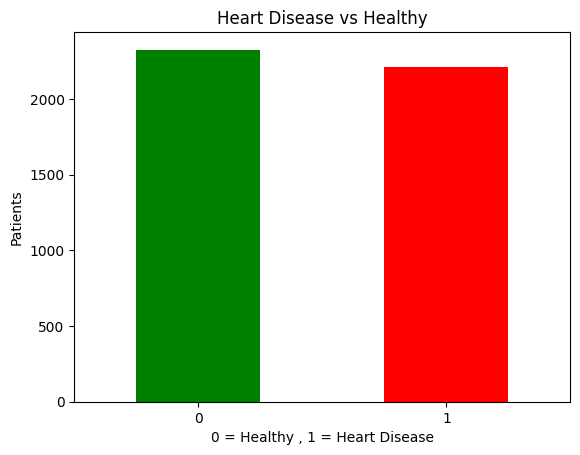

In [27]:
df['target'].value_counts().plot(kind='bar',color=['green','red'])
plt.title('Heart Disease vs Healthy')
plt.xlabel('0 = Healthy , 1 = Heart Disease')
plt.ylabel('Patients')
plt.xticks(rotation=0)
plt.show()

In [28]:
df['bp_per_age'] = df['blood_pressure'] / df['age']
df['cholesterol_per_age'] = df['cholesterol'] / df['age']
df['heart_score'] = df['exercise_hours'] - df['stress_level'] / df['stress_level']
df['risk_score'] = df['smoker'] + df['diabetes'] + df['alcohol'] + df['family_history']

print('New Features Added!')
print(df[['bp_per_age' , 'cholesterol_per_age' , 'heart_score', 'risk_score' ]])

New Features Added!
      bp_per_age  cholesterol_per_age  heart_score  risk_score
10      3.846154             5.307692          1.0           2
11      3.307692             3.250000          0.0           3
12      2.734375             4.984375          1.0           4
13      2.823529             5.632353          7.0           3
14      2.365385             7.653846          0.0           3
...          ...                  ...          ...         ...
4995    5.580645             7.741935          3.0           2
4996    2.258621             8.068966          8.0           2
4997    3.551724            12.965517          3.0           3
4998    2.327586             2.275862          6.0           2
4999    1.780822             4.712329          8.0           2

[4534 rows x 4 columns]


In [29]:
X = df.drop('target' , axis=1)
Y = df['target']
print(f'X: {len(X)} rows')
print(f'Y: {len(Y)} rows')
print(f'Features: {X.columns.tolist()}')



X: 4534 rows
Y: 4534 rows
Features: ['age', 'gender', 'chest_pain_type', 'blood_pressure', 'cholesterol', 'blood_sugar', 'max_heart_rate', 'exercise_angina', 'smoker', 'diabetes', 'bmi', 'stress_level', 'sleep_hours', 'exercise_hours', 'alcohol', 'family_history', 'bp_per_age', 'cholesterol_per_age', 'heart_score', 'risk_score']


In [30]:
X_train , X_test , Y_train , Y_test = train_test_split(X , Y , test_size=0.2, random_state=42)
print(f'Training: {len(X_train)} patients')
print(f'Testing: {len(X_test)} patients')

Training: 3627 patients
Testing: 907 patients


In [31]:
model1 = LogisticRegression()
model1.fit(X_train , Y_train)

model2 = DecisionTreeClassifier()
model2.fit(X_train , Y_train)

model3 = RandomForestClassifier()
model3.fit(X_train , Y_train)

print('Teeno Models Train Done!')



Teeno Models Train Done!


In [32]:
acc1 = accuracy_score(Y_test , model1.predict(X_test))
acc2 = accuracy_score(Y_test , model2.predict(X_test))
acc3 = accuracy_score(Y_test , model3.predict(X_test))

print(f'Logistic Regression: {acc1*100:.2f}%')
print(f'Decision Tree: {acc2*100:.2f}%')
print(f'Random Forest: {acc3*100:.2f}%')

Logistic Regression: 60.09%
Decision Tree: 53.80%
Random Forest: 59.32%


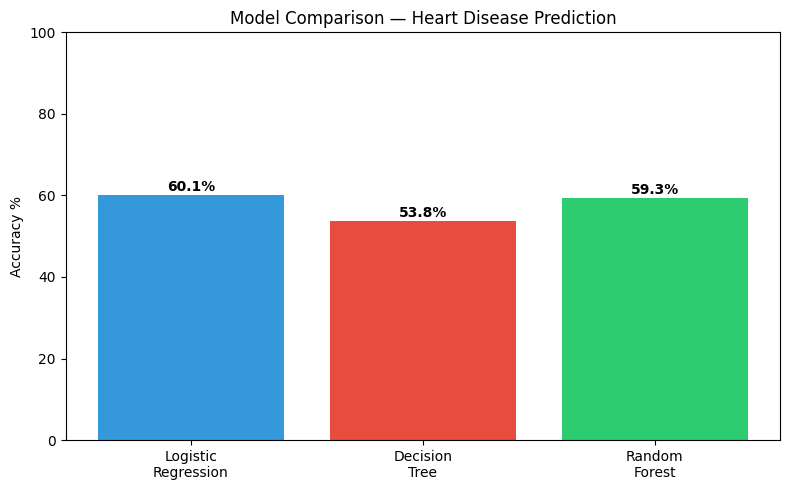

In [33]:
models_names = ['Logistic\nRegression', 'Decision\nTree', 'Random\nForest']
accuracies = [acc1*100, acc2*100, acc3*100]

plt.figure(figsize=(8,5))
bars = plt.bar(models_names, accuracies,
               color=['#3498db','#e74c3c','#2ecc71'])
plt.title('Model Comparison — Heart Disease Prediction')
plt.ylabel('Accuracy %')
plt.ylim([0, 100])

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{acc:.1f}%',
             ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [34]:
models = {
    'Logistic Regression': acc1,
    'Decision Tree': acc2,
    'Random Forest': acc3
}
best = max(models, key=models.get)
print(f'Best Model: {best}')
print(f'Accuracy: {models[best]*100:.2f}%')

Best Model: Logistic Regression
Accuracy: 60.09%
